# Forecast Using the TabPFN Family


TimeCopilot ships a single `TabPFN` class that supports TabPFN-2 (default) and TabPFN-3 checkpoints. Pass `model_path` to select the checkpoint:

| Version | `model_path` | Notes |
|---------|-------------|-------|
| **TabPFN-2** (default) | `tabpfn-v2-regressor-2noar4o2.ckpt` | TabPFN NC license |
| **TabPFN-3** | `tabpfn-v3-regressor-v3_20260506_timeseries.ckpt` | Finetuned TS checkpoint; TabPFN NC license; LOCAL only |

*Requirements*:

    - Python 3.10 – 3.12
    - LOCAL mode (default when CUDA is available): accept terms at [ux.priorlabs.ai](https://ux.priorlabs.ai) and set `TABPFN_TOKEN`
    - TabPFN-3 recommends `context_length=32768`; TabPFN-2 defaults to 4096

**License:** TabPFN-2.6+ and TabPFN-3 weights use the TabPFN Non-Commercial license. Commercial production requires a [Prior Labs license or API](https://docs.priorlabs.ai/models).

In this example we compare TabPFN-2 and TabPFN-3 on event pageview data.


## Import libraries


In [1]:
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

from timecopilot import TimeCopilotForecaster

load_dotenv(Path(".env"))

if sys.version_info >= (3, 13):
    raise RuntimeError("TabPFN requires Python < 3.13")


/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)


In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data


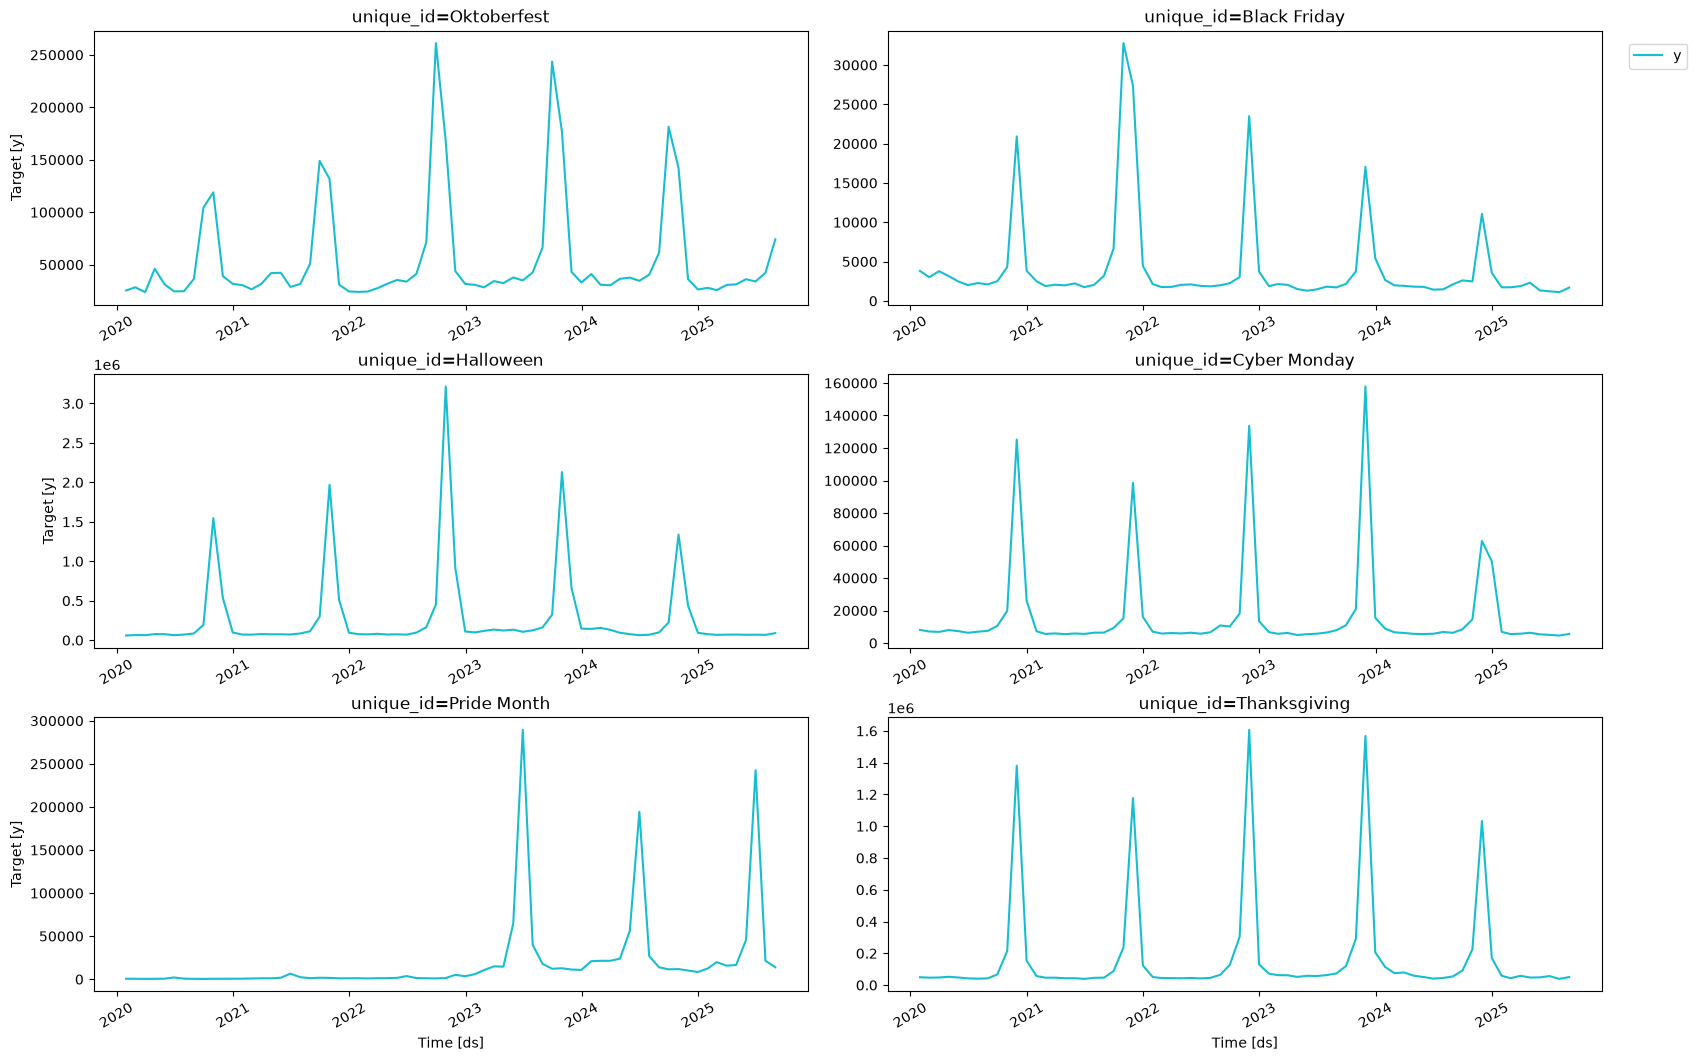

In [3]:
TimeCopilotForecaster.plot(df)


## Import the models


In [4]:
from tabpfn_time_series import TabPFNMode

from timecopilot.models.foundation.tabpfn import TABPFN_V2_MODEL, TABPFN_V3_MODEL, TabPFN


## Create a TimeCopilotForecaster

We compare TabPFN-2 with TabPFN-3 in LOCAL mode. Each model gets a distinct `alias`.


In [5]:
models = [
    TabPFN(
        model_path=TABPFN_V2_MODEL,
        mode=TabPFNMode.LOCAL,
        alias="TabPFN-2",
    ),
    TabPFN(
        model_path=TABPFN_V3_MODEL,
        mode=TabPFNMode.LOCAL,
        context_length=32768,
        alias="TabPFN-3",
    ),
]

tcf = TimeCopilotForecaster(models=models)


## Generate forecast

TabPFN outputs nine fixed quantiles (0.1 through 0.9). Pass `level=[0, 20, 40, 60, 80]` to request all supported prediction intervals.


In [6]:
level = [0, 20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=12, freq="MS", level=level)


0it [00:00, ?it/s]

Predicting time series:   0%|          | 0/6 [00:00<?, ?it/s]

Predicting time series: 100%|██████████| 6/6 [00:00<00:00, 41.83it/s]

Predicting time series: 100%|██████████| 6/6 [00:00<00:00, 32.16it/s]

1it [00:16, 16.76s/it]

...

0it [00:00, ?it/s]

Predicting time series:   0%|          | 0/6 [00:00<?, ?it/s]

Predicting time series: 100%|██████████| 6/6 [00:00<00:00, 580.50it/s]

1it [00:17, 17.04s/it]

1it [00:17, 17.18s/it]

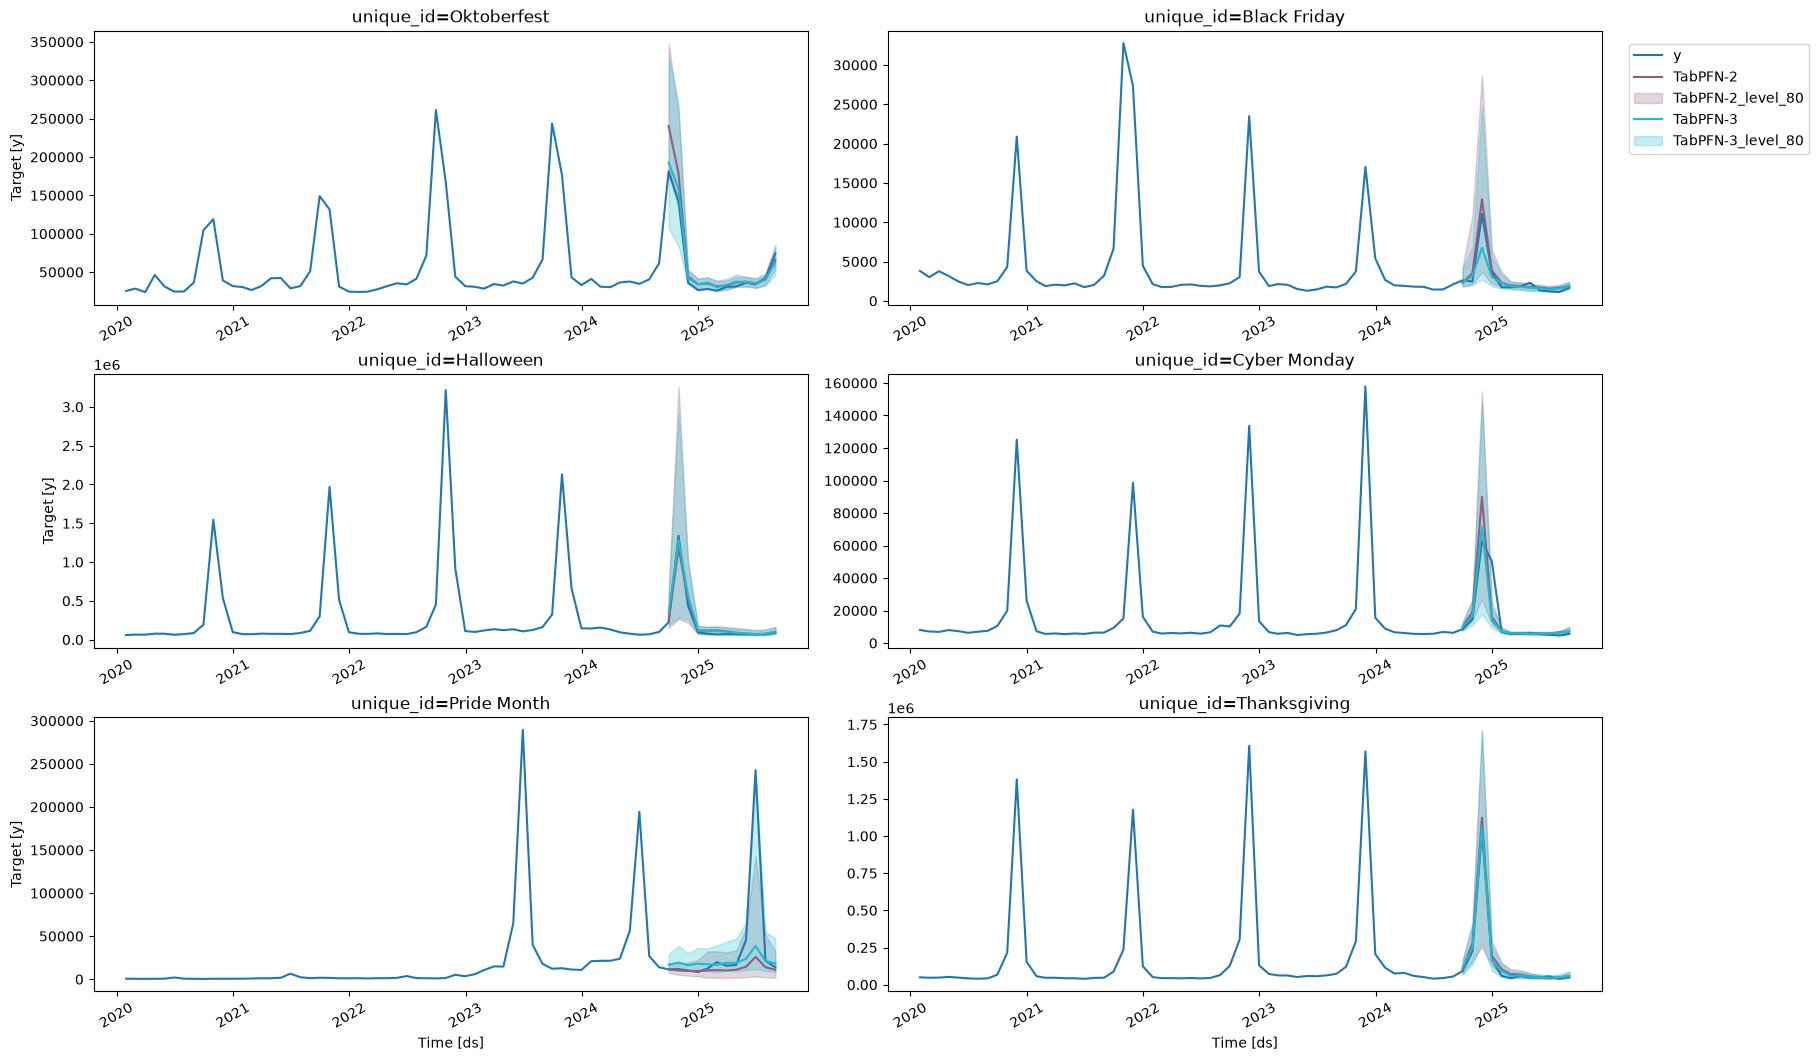

In [7]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [8]:
cv_df.head()


,unique_id,ds,cutoff,y,TabPFN-2,TabPFN-2-lo-0,TabPFN-2-hi-0,TabPFN-2-lo-20,TabPFN-2-hi-20,TabPFN-2-lo-40,...,TabPFN-3-lo-0,TabPFN-3-hi-0,TabPFN-3-lo-20,TabPFN-3-hi-20,TabPFN-3-lo-40,TabPFN-3-hi-40,TabPFN-3-lo-60,TabPFN-3-hi-60,TabPFN-3-lo-80,TabPFN-3-hi-80
0,Black Friday,2024-09-30,2024-09-01,2607,2283.965088,2283.965088,2283.965088,2177.424561,2420.626465,2081.235596,...,2306.467773,2306.467773,2169.607178,2497.994629,2056.207275,2797.267334,1941.594482,3244.148438,1798.154785,4146.946777
1,Black Friday,2024-10-31,2024-09-01,2470,3523.283203,3523.283203,3523.283203,3156.973877,3964.171875,2814.589111,...,3155.802979,3155.802979,2800.380371,3559.806152,2491.012451,4029.166504,2239.562500,4868.718750,1980.670654,6789.798340
2,Black Friday,2024-11-30,2024-09-01,11058,12908.764648,12908.764648,12908.764648,9775.419922,16364.140625,7223.555664,...,6755.500000,6755.500000,5224.051270,9573.415039,4197.266113,15283.360352,3451.474609,19639.794922,2746.735352,24622.894531
3,Black Friday,2024-12-31,2024-09-01,3548,3868.746582,3868.746582,3868.746582,3513.119385,4233.543945,3093.505371,...,3064.281494,3064.281494,2702.104736,3447.574219,2388.743896,3879.081543,2119.647461,4505.389160,1864.812134,5696.427734
4,Black Friday,2025-01-31,2024-09-01,1724,2284.322510,2284.322510,2284.322510,2164.592773,2436.935303,2059.958984,...,2201.597168,2201.597168,2054.866211,2375.402832,1918.067749,2579.746582,1779.724976,2839.138428,1587.375732,3371.126953


## Evaluation


In [9]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)


metric,mase,scaled_crps
TabPFN-3,0.789,0.254
TabPFN-2,1.020,0.279
